# makemore_wavenet

## preparation

import code from lec04

In [1]:
# import module
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read file
words = open('../names.txt', 'r').read().splitlines()

In [3]:
# utility functions
from string import ascii_lowercase
stoi = {c:i+1 for i, c in enumerate(ascii_lowercase)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}
vocab_size = len(itos)

In [84]:
# build and split the dataset
block_size = 8

def build_dataset(words):  
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])        # 80% training set
Xdev, Ydev = build_dataset(words[n1:n2])    # 10% dev set
Xte, Yte = build_dataset(words[n2:])        # 10% test set

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


build same API as nn.Module in PyTorch

In [85]:
torch.manual_seed(42)    # seed rng for reproducibility

In [134]:
# PyTorchifying the code (mimicking the nn.Module API):
# These classes replicate the standard PyTorch interface, eliminating boilerplate 
# and allowing us to build neural networks declaratively.
# 
# `__init__(self, *args)` : 
#   Initializes the layer instance and storage the arguments that are used in layer.
# `__call__(self, x)` :
#   Executes the forward pass,
#   x means the data passed from the layer right before.
# `parameters(self)` :
#   Returns the learnable parameters (for the backward pass and update).

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weights = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.biases = torch.zeros((fan_out)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weights
        if self.biases is not None:
            self.out += self.biases
        return self.out

    def parameters(self):
        return [self.weights] + ([self.biases] if self.biases is not None else [])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        # Note: As per the original paper, we track the running variance here 
        # rather than the running std used in Lec04.
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            self.bnmean = x.mean(dim=0, keepdim=True)
            self.bnvar = x.var(dim=0, keepdim=True)
        else:
            self.bnmean = self.running_mean
            self.bnvar = self.running_var
        
        bnhat = (x - self.bnmean) * torch.sqrt(self.bnvar+self.eps)**(-1)
        self.out = self.gamma * bnhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*self.bnmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*self.bnvar
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

class Embedding:
    def __init__(self, emb_num, emb_dim):
        # weights for mimicing nn.Embedding.weights of pytorch is C that we used before
        self.weights = torch.randn((emb_num, emb_dim))
    
    def __call__(self, x):
        self.out = self.weights[x]
        return self.out
    
    def parameters(self):
        return [self.weights]

# Concatenate embedding by using Flatten
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
    
    def __call__(self, x):
        B, T, C = x.shape
        self.out = x.view(B, T//self.n, C*self.n)
        if self.out.shape[1] == 1:
            self.out = self.out.squeeze(dim=1)
        return self.out
    
    def parameters(self):
        return []

# Mimic nn.Sequential to replace the Layer list below
class Sequential:
    def __init__(self, layers):
        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get all parameters in model
        return [p for layer in self.layers for p in layer.parameters()]

In [135]:
# build neural network
emb_dim = 10    # dimension of embedding vectors
ns_num_h = 200    # the number of neurons in hidden layer

model = Sequential([
    Embedding(vocab_size, emb_dim),
    FlattenConsecutive(2), Linear(emb_dim*2, ns_num_h, bias=False), BatchNorm1d(ns_num_h), Tanh(),
    FlattenConsecutive(2), Linear(ns_num_h*2, ns_num_h, bias=False), BatchNorm1d(ns_num_h), Tanh(),
    FlattenConsecutive(2), Linear(ns_num_h*2, ns_num_h, bias=False), BatchNorm1d(ns_num_h), Tanh(),
    Linear(ns_num_h, vocab_size)
])

with torch.no_grad():
    model.layers[-1].weights *= 0.1

parameters = model.parameters()
for p in parameters:
    p.requires_grad = True

In [136]:
# train
max_steps = 200000
batch_size = 32
lossk = []

# for layer in model.layers:
#     if isinstance(layer, BatchNorm1d):
#         layer.training = True

for k in range(max_steps):

    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if k < 150000 else 0.01
    for p in parameters:
        p.data += -p.grad * lr

    # monitor
    if k % 10000 == 0: # print every once in a while
        print(f'{k:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossk.append(loss.log10().item())

    # if k > 10000: break

      0/ 200000: 3.3087
  10000/ 200000: 2.2402
  20000/ 200000: 2.1260
  30000/ 200000: 1.7103
  40000/ 200000: 2.0505
  50000/ 200000: 1.7624
  60000/ 200000: 2.0496
  70000/ 200000: 1.9152
  80000/ 200000: 2.2105
  90000/ 200000: 1.8905
 100000/ 200000: 2.1604
 110000/ 200000: 1.5833
 120000/ 200000: 2.1610
 130000/ 200000: 1.6763
 140000/ 200000: 1.8099
 150000/ 200000: 2.2389
 160000/ 200000: 1.6242
 170000/ 200000: 1.7729
 180000/ 200000: 2.0395
 190000/ 200000: 1.7806


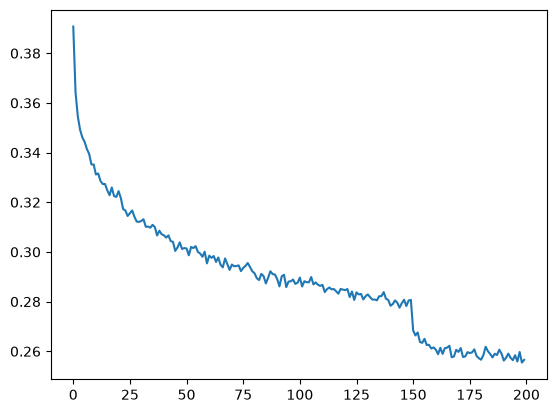

In [137]:
plt.plot(torch.tensor(lossk).view(-1, 1000).mean(1))

In [138]:
# switch to eval mode and use running statistics
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

In [139]:
# evaluate the model and adjust hyperparameters
@torch.no_grad()
def split_loss(split):
    Xb, Yb = {
        'tr': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'te': (Xte, Yte)
    }[split]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    print(f"{split} loss: {loss.item():.4f}")
    return loss.data

tr_loss = split_loss('tr')
dev_loss = split_loss('dev')

tr loss: 1.7804
dev loss: 1.9810


In [140]:
# sample from model
with torch.no_grad():

    for _ in range(20):

        out = []
        context = [0] * block_size
        
        while True:
            logits = model(torch.tensor([context]))
            probs = F.softmax(logits, dim=-1)
            ix = torch.multinomial(probs, num_samples=1, replacement=True).item()
            out.append(itos[ix])
            context = context[1:] + [ix]
            if ix == 0: break

        print(''.join(out))

shaiphiz.
kanya.
salede.
sariah.
yasphoni.
tayvin.
horan.
prycie.
deny.
harl.
mekhani.
xayla.
aristen.
lindon.
decin.
rain.
samyia.
dahman.
jahsa.
jazilynn.
